# 2장 2강: 퍼널 분석 — 전환율·이탈률 측정 원리 — 실습문제

## 실습 목표

- Ravenstack의 구독 여정을 순차적인 퍼널 단계로 정의할 수 있다.
- 이벤트 횟수와 고유 구독 수의 차이를 설명할 수 있다.
- 단계별 전환율과 이탈률을 계산할 수 있다.
- 막대형 퍼널을 시각화하고 이탈이 집중된 구간을 찾을 수 있다.
- 세그먼트별 퍼널을 비교하고 개선 가설을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

이번 실습에서는 Ravenstack의 구독 여정을 다음과 같이 단순화합니다.

| 순서 | 퍼널 단계 | 집계 기준 |
|---:|---|---|
| 1 | 구독 시작 | `subscriptions`에 존재하는 고유 구독 |
| 2 | 기능 사용 | 기능 사용 기록이 한 번 이상 있는 구독 |
| 3 | 유료 구독 | 기능 사용 구독 중 `is_trial == False`인 구독 |
| 4 | 현재 유료 유지 | 이전 단계 구독 중 `end_date`가 비어 있는 구독 |

> 이 퍼널은 전환율 계산 원리를 익히기 위한 학습용 정의입니다. `is_trial`은 실제 유료 전환 시각을 기록한 이벤트가 아니므로 실제 전환 소요 시간이나 행동 순서를 완전히 재구성할 수는 없습니다.

> 풀이 데이터: 이 폴더의 `data/` CSV. RavenStack은 River @ Rivalytics의 합성 교육용 데이터다. 실제 사업 성과로 일반화하지 않는다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 구독 ID의 고유 개수와 기능 사용 이벤트 행 수를 확인하세요.
7. `usage_id`의 중복 개수를 확인하고, 중복 ID를 바로 삭제하면 안 되는 이유를 생각해보세요.

In [1]:
from pathlib import Path
import pandas as pd
DATA_DIR = Path('data')

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager
if 'Malgun Gothic' in {f.name for f in font_manager.fontManager.ttflist}:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams.update({'axes.unicode_minus': False, 'figure.figsize': (8,4), 'font.size': 11})
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
def show_rates(frame):
    display(frame.style.format({c: '{:.2%}' for c in frame.columns if 'rate' in str(c) or 'conversion' in str(c)}, na_rep='—'))
def bars(series, title, ylabel, percent=False):
    ax = (series * (100 if percent else 1)).plot.bar(color='#32689b', rot=0)
    ax.set(title=title, ylabel=ylabel, xlabel='')
    ax.set_ylim(bottom=0)
    plt.tight_layout(); plt.show()
def make_funnel(counts, labels):
    f = pd.DataFrame({'count': counts}, index=labels)
    prev = f['count'].shift().replace(0, np.nan)
    f['conversion_rate'] = f['count'] / prev
    f['drop_rate'] = 1 - f.conversion_rate
    f['drop_count'] = f['count'].shift() - f['count']
    return f

subscriptions = pd.read_csv(DATA_DIR / 'ravenstack_subscriptions.csv')
feature_usage = pd.read_csv(DATA_DIR / 'ravenstack_feature_usage.csv')
tables = {'subscriptions':subscriptions,'feature_usage':feature_usage}
for name, df in tables.items():
    for col in df.columns:
        if col.endswith('_date') or col in ['submitted_at', 'closed_at']:
            df[col] = pd.to_datetime(df[col], errors='raise')
    print(name, df.shape)
    display(df.head())
    display(pd.DataFrame({'dtype':df.dtypes.astype(str), 'missing':df.isna().sum()}))
if 'subscriptions' in tables:
    assert subscriptions.subscription_id.is_unique
    display(subscriptions.mrr_amount.describe())
    display(subscriptions.plan_tier.value_counts())
if 'feature_usage' in tables:
    print('usage_id 중복:', feature_usage.usage_id.duplicated().sum())
    print('구독 수 / 이벤트 행 수:', subscriptions.subscription_id.nunique(), len(feature_usage))
    display(feature_usage.feature_name.value_counts())
    display(feature_usage.usage_count.describe())
    assert feature_usage.subscription_id.isin(subscriptions.subscription_id).all()

print('중복 ID는 재전송/서로 다른 기록인지 확인한 뒤 처리해야 한다.')

subscriptions (5000, 14)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True


,dtype,missing
subscription_id,object,0
account_id,object,0
start_date,datetime64[ns],0
end_date,datetime64[ns],4514
plan_tier,object,0
seats,int64,0
mrr_amount,int64,0
arr_amount,int64,0
is_trial,bool,0
upgrade_flag,bool,0


feature_usage (25000, 8)


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


...

plan_tier
Enterprise    1723
Pro           1675
Basic         1602
Name: count, dtype: int64

usage_id 중복: 21
구독 수 / 이벤트 행 수: 5000 25000


feature_name
feature_32    659
feature_12    659
feature_6     655
feature_17    651
feature_34    650
             ... 
feature_19    589
feature_18    588
feature_35    587
feature_5     577
feature_23    563
Name: count, Length: 40, dtype: int64

count    25000.000000
mean        10.021000
std          3.143729
min          0.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         26.000000
Name: usage_count, dtype: float64

중복 ID는 재전송/서로 다른 기록인지 확인한 뒤 처리해야 한다.


---

## 필수 1. 전체 구독 퍼널의 전환율과 이탈률 계산하기

### 문제 1-1. Ravenstack 구독은 어느 구간에서 가장 많이 이탈하는가?

#### 문제 설명

전체 Ravenstack 구독을 대상으로 네 단계의 고유 구독 수를 계산하고, 각 구간의 전환율과 이탈률을 구하세요.

각 단계는 반드시 앞 단계를 통과한 구독만 포함해야 합니다. 예를 들어 유료 구독 단계는 전체 유료 구독이 아니라 **기능 사용 단계에 포함되면서 유료인 구독**으로 계산합니다.

#### 요구사항

1. 전체 구독 ID를 `started_ids`로 만드세요.
2. 기능 사용 기록이 있는 구독 ID와 `started_ids`의 교집합을 `used_ids`로 만드세요.
3. `used_ids`와 체험이 아닌 구독 ID의 교집합을 `paid_ids`로 만드세요.
4. `paid_ids`와 종료일이 비어 있는 구독 ID의 교집합을 `retained_paid_ids`로 만드세요.
5. 단계명과 고유 구독 수를 사용하여 `funnel` 데이터프레임을 만드세요.
6. 다음 식으로 구간 전환율과 이탈률을 계산하세요.
   - 전환율 = 현재 단계 구독 수 ÷ 이전 단계 구독 수
   - 이탈률 = 1 - 전환율
7. 각 구간의 이탈 구독 수도 계산하세요.
8. 단계별 구독 수를 막대그래프로 시각화하세요.
9. 전환율이 가장 낮은 구간을 찾고 개선 가설을 한 가지 제안하세요.

#### 해석 질문

**Q1.** 기능 사용 이벤트 행 수 대신 고유 구독 수를 사용해야 하는 이유는 무엇인가요?  
**Q2.** 전환율이 가장 낮고 이탈 구독 수가 가장 많은 구간은 어디인가요?  
**Q3.** 전환율과 이탈률을 더하면 얼마인가요?  
**Q4.** 낮은 전환율만으로 실제 이탈 원인을 확정할 수 있나요?

#### 제출 결과

- 단계별 고유 구독 집합
- `funnel` 데이터프레임
- 전환율·이탈률·이탈 구독 수
- 막대형 퍼널
- 이탈 집중 구간과 개선 가설
- Q1~Q4 답변

,count,conversion_rate,drop_rate,drop_count
구독 시작,5000,—,—,—
기능 사용,4967,99.34%,0.66%,33.000000
유료 구독,4193,84.42%,15.58%,774.000000
현재 유료 유지,3788,90.34%,9.66%,405.000000


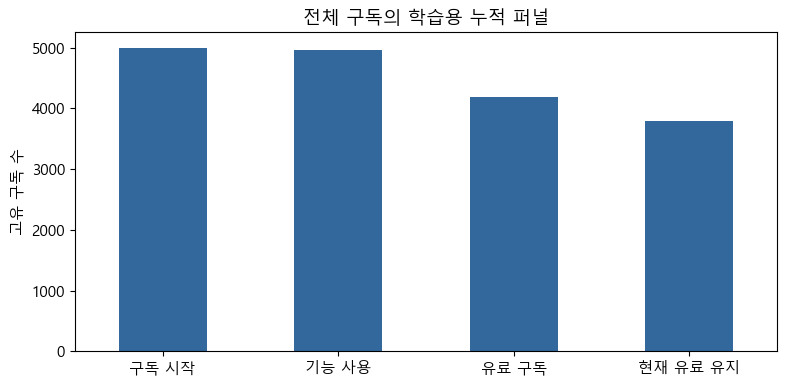

In [2]:
started_ids = set(subscriptions.subscription_id)
used_ids = started_ids & set(feature_usage.subscription_id)
paid_ids = used_ids & set(subscriptions.loc[~subscriptions.is_trial,'subscription_id'])
retained_paid_ids = paid_ids & set(subscriptions.loc[subscriptions.end_date.isna(),'subscription_id'])
stage_names = ['구독 시작','기능 사용','유료 구독','현재 유료 유지']
funnel = make_funnel(list(map(len,[started_ids,used_ids,paid_ids,retained_paid_ids])), stage_names)
assert retained_paid_ids <= paid_ids <= used_ids <= started_ids
show_rates(funnel)
bars(funnel['count'], '전체 구독의 학습용 누적 퍼널', '고유 구독 수')

### 필수 1 답변
- **Q1.** 반복 이벤트를 세면 동일 구독이 여러 번 분모·분자에 들어가 전환율이 왜곡된다.
- **Q2.** 최저 전환 도달 단계는 유료 구독 (84.42%), 최대 이탈 도달 단계는 유료 구독 (774개)이다. 각각 바로 이전 단계에서의 이동이다.
- **Q3.** 분모가 있는 구간은 100%다.
- **Q4.** 원인은 확정할 수 없다. 기능 가치가 충분히 전달되지 않아 유료 전환이 낮다는 가설을 세우고 사용 행동·결제 실패·설문을 확인한다. 상태 기반 실습 퍼널이므로 실제 결제 시각의 순서는 확인되지 않는다.

---

## 필수 2. 요금제별 퍼널 비교하기

### 문제 2-1. 요금제에 따라 이탈 구간이 다른가?

#### 문제 설명

`Basic`, `Pro`, `Enterprise` 요금제별로 동일한 퍼널을 계산하고 구간 전환율을 비교하세요. 그룹별 비교를 통해 특정 요금제에 문제가 집중되어 있는지 확인합니다.

#### 요구사항

1. 요금제별 퍼널을 계산하는 함수 `calculate_segment_funnel()`을 작성하세요.
2. 함수는 필수 1과 동일한 네 단계의 고유 구독 수와 구간 전환율을 반환해야 합니다.
3. 세 요금제의 결과를 결합하여 `plan_funnel`을 만드세요.
4. 첫 단계를 제외한 구간별 전환율을 요금제별 막대그래프로 시각화하세요.
5. 모든 요금제와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
6. 해당 요금제와 구간을 우선 점검 대상으로 정하고 개선 가설을 한 가지 제안하세요.
7. 요금제별 차이가 크지 않을 경우 해석에서 그 사실도 언급하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 요금제와 구간의 조합은 무엇인가요?  
**Q2.** 요금제별 퍼널 비교가 전체 퍼널만 보는 것보다 유용한 이유는 무엇인가요?  
**Q3.** 관찰된 요금제별 차이는 큰 편인가요?  
**Q4.** 개선 가설을 확인하기 위해 어떤 데이터를 추가로 살펴볼 수 있나요?

#### 제출 결과

- 요금제별 퍼널 계산 함수
- `plan_funnel` 결과
- 요금제별 전환율 그래프
- 우선 점검 대상과 개선 가설
- Q1~Q4 답변

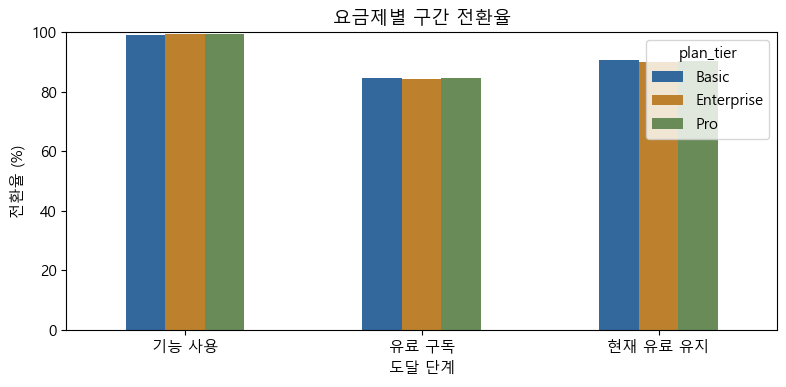

stage
구독 시작            NaN
기능 사용       0.351563
유료 구독       0.382757
현재 유료 유지    0.666529
Name: 요금제 간 차이 (%p), dtype: float64

In [3]:
def calculate_segment_funnel(segment):
    ids = set(segment.subscription_id)
    return make_funnel([len(ids & s) for s in [started_ids,used_ids,paid_ids,retained_paid_ids]],stage_names)
plan_funnel = pd.concat({k:calculate_segment_funnel(g) for k,g in subscriptions.groupby('plan_tier')},names=['plan_tier','stage'])
show_rates(plan_funnel)
def compare_funnel(frame, title):
    (frame.conversion_rate.unstack(0).iloc[1:]*100).plot.bar(rot=0, color=['#32689b','#bd812e','#688b57'])
    plt.title(title); plt.ylabel('전환율 (%)'); plt.ylim(0,100); plt.xlabel('도달 단계'); plt.tight_layout(); plt.show()
compare_funnel(plan_funnel, '요금제별 구간 전환율')
display((plan_funnel.conversion_rate.unstack(0).max(axis=1)-plan_funnel.conversion_rate.unstack(0).min(axis=1)).mul(100).rename('요금제 간 차이 (%p)'))

### 필수 2 답변
- **Q1.** ('Enterprise', '유료 구독') 조합, 84.19%다.
- **Q2.** 전체 평균에 가려진 상품별 개선 대상을 찾는다.
- **Q3.** 구간별 요금제 격차는 위 %p 표와 같다. 최대 격차도 0.67%p이므로 차이를 과장하지 않는다.
- **Q4.** 낮은 구간에서 가치 전달이 부족하다는 가설을 세우고 온보딩 단계, 기능 사용량, 요금제 선택 이유와 해지 사유를 비교한다.

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 결제 주기별 퍼널 비교하기

#### 문제 설명

월간 결제 구독과 연간 결제 구독의 퍼널을 비교하여 상대적으로 전환율이 낮은 그룹과 구간을 찾으세요.

> 이 과제는 필수 2에서 만든 함수와 분석 절차를 `billing_frequency`에 동일하게 적용하는 문제입니다.

#### 요구사항

1. `calculate_segment_funnel()`을 사용하여 `monthly`, `annual`의 퍼널을 계산하세요.
2. 두 결과를 결합하여 `billing_funnel`을 만드세요.
3. 첫 단계를 제외한 구간 전환율을 결제 주기별 막대그래프로 시각화하세요.
4. 모든 결제 주기와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
5. 해당 그룹과 구간에 대한 개선 가설을 한 가지 제안하세요.
6. 퍼널 결과만으로 원인을 확정할 수 없는 이유와 추가 확인할 데이터를 설명하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 결제 주기와 구간의 조합은 무엇인가요?  
**Q2.** 해당 구간의 전환율과 이탈률은 얼마인가요?  
**Q3.** 이 결과만으로 결제 주기가 이탈의 원인이라고 말할 수 있나요?

#### 제출 결과

- `billing_funnel` 결과
- 결제 주기별 전환율 그래프
- 우선 점검 대상과 개선 가설
- 분석의 한계와 추가 확인 데이터
- Q1~Q3 답변

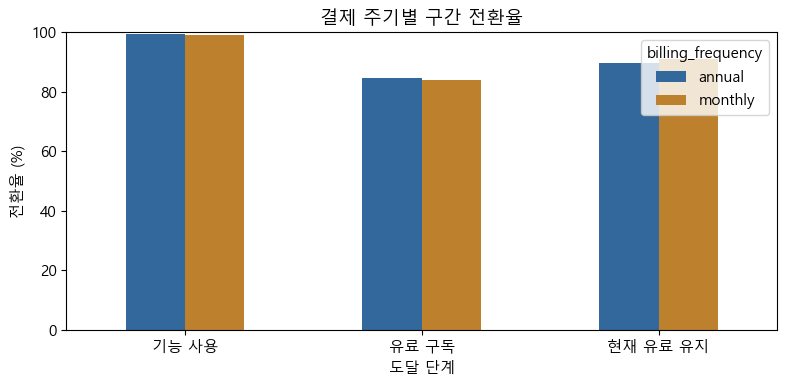

In [4]:
billing_funnel = pd.concat({k:calculate_segment_funnel(g) for k,g in subscriptions.groupby('billing_frequency')},names=['billing_frequency','stage'])
show_rates(billing_funnel)
compare_funnel(billing_funnel, '결제 주기별 구간 전환율')

### 과제 1 답변
- **Q1.** monthly 결제의 **기능 사용 → 유료 구독** 구간이 가장 낮다.
- **Q2.** 전환율 84.13%, 이탈률 15.87%다.
- **Q3.** 결제 주기의 원인 효과라고 말할 수 없다. 월간 결제 가격 대비 기능 가치가 불명확하다는 가설을 검토하고, 고객 규모·가입 시점·요금제를 맞춰 가격 안내 및 결제 실패 로그를 비교한다. 가치 안내 개선의 효과는 별도 실험으로 검증한다.

---

## 실습 마무리

아래 질문에 답하세요.

1. 이번 실습의 퍼널 단계를 어떻게 정의했나요?
2. 단계별 사용자 수 대신 어떤 식별자의 고유 개수를 사용했나요?
3. 전환율과 이탈률은 어떻게 계산했나요?
4. 전체 퍼널에서 가장 큰 문제가 나타난 구간은 어디였나요?
5. 퍼널 분석 결과와 실제 원인을 왜 구분해야 하나요?

### 마무리 답변
1. 구독 시작→기능 사용→유료 구독→현재 유료 유지로 정의했다.
2. subscription_id의 고유 개수를 셌다.
3. 현재/이전 단계가 전환율이고 1−전환율이 이탈률이다.
4. 위 표의 최저 전환 구간과 최대 이탈 수 구간을 각각 확인했다.
5. 집단 구성과 관찰 기간이 다를 수 있어 퍼널은 원인의 증명이 아니다.